### 教程地址：`https://github.com/Bin-Cao/PyWPEM/tree/main/Tutorial`
### github 项目地址： `https://github.com/Bin-Cao/PyWPEM`
### 软件文档： `https://pyxplore.netlify.app/intro.html`
### 项目主页： `https://bin-cao.github.io/PyWPEM`

### 致谢合作单位：
+ **香港科技大学（广州）**
+ **上海大学**
+ **GreenDynamics** 


---

## 打开环境 打开jupyter 

In [ ]:
conda activate myenv

In [ ]:
jupyter notebook

## 本节介绍： 包含完整执行路径、文件基础说明、算法基础说明、参数基础说明

## 初探PyXplore

In [1]:
pip show PyXplore

Name: PyXplore
Version: 2026.8.17
Summary: A powder X-ray diffraction analysis and materials-characterization toolkit
Home-page: https://github.com/Bin-Cao/PyWPEM
Author: Bin Cao
Author-email: binjacobcao@gmail.com
License: MIT
Location: /Users/jacob/miniconda3/envs/pywpem/lib/python3.10/site-packages
Requires: ase, ipywidgets, matplotlib, monty, numpy, pandas, plotly, pymatgen, PyWavelets, scikit-learn, scipy, spglib, sympy, tensorflow, tqdm
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [2]:
# 导入
from PyXplore import WPEM
import pandas as pd


██╗    ██╗██████╗ ███████╗███╗   ███╗
██║    ██║██╔══██╗██╔════╝████╗ ████║
██║ █╗ ██║██████╔╝█████╗  ██╔████╔██║
██║███╗██║██╔═══╝ ██╔══╝  ██║╚██╔╝██║
╚███╔███╔╝██║     ███████╗██║ ╚═╝ ██║
 ╚══╝╚══╝ ╚═╝     ╚══════╝╚═╝     ╚═╝                                                  

A Diffraction Refinement Software
Bin Cao, HKUST(Guangzhou), https://bin-cao.github.io
Manual: https://pyxplore.netlify.app/
Paper : https://arxiv.org/abs/2602.16372
URL : https://github.com/Bin-Cao/PyWPEM
Executed on : 2026-08-17 16:13:07  | Have a great day.


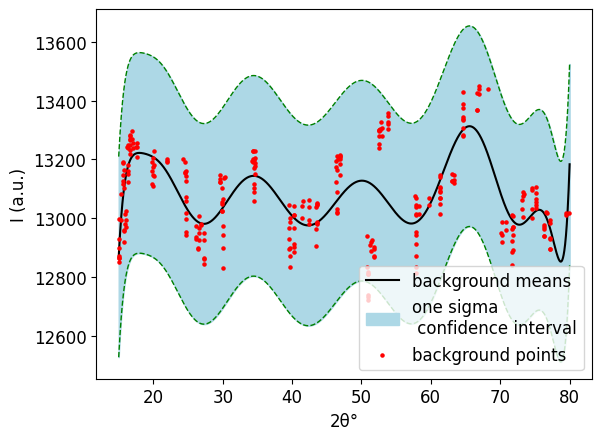

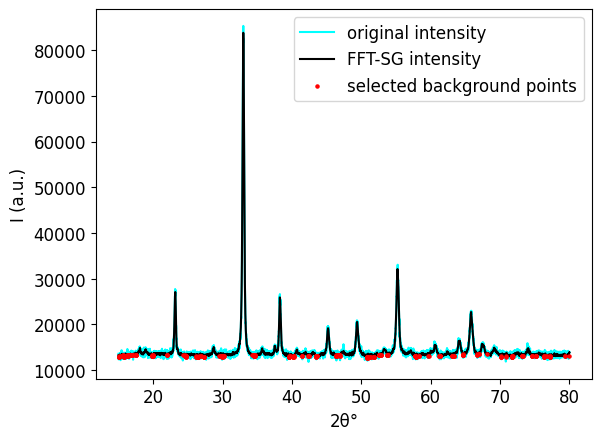

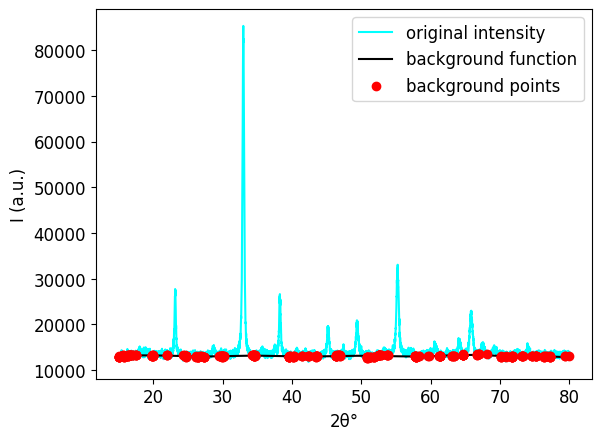

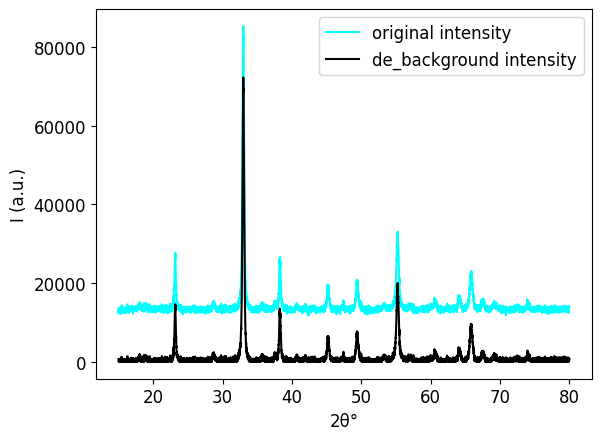

<Figure size 640x480 with 0 Axes>

In [3]:
# 分析背底
intensity_csv = pd.read_csv(r'intensity.csv',header=None )
var = WPEM.BackgroundFit(intensity_csv,lowAngleRange=17,poly_n=13,bac_split=16,bac_num=300)

---

# V2026.8.17 新增功能：结构弛豫

# V2026.8.17 New Feature: Structure Relaxation

# 代码会自动对输入结构进行预优化。建议先执行这一步，以获得更合理的初始结构，然后再进行后续操作。

## The code will automatically pre-optimize the input structure. It is recommended to perform this step first to obtain a more reasonable initial structure before proceeding with subsequent operations.


In [6]:
results = WPEM.StructureSolve(
    no_bac_intensity_file='./ConvertedDocuments/no_bac_intensity.csv',
    cif_file='Mn2O3.cif'
)

---

In [ ]:
# 得到衍射指数 HKL
latt, AtomCoordinates,des = WPEM.CIFpreprocess(filepath='Mn2O3.cif',two_theta_range=(15,75))

In [ ]:
# 简单配置并修晶格

# The wavelength is set according to the actual light source
wavelength = [1.540593, 1.544414]
# The file name of non-background data (2theta-intensity data)
no_bac_intensity_file = "no_bac_intensity.csv" 
# The file name of raw/original data (2theta-intensity data)
original_file = "intensity.csv"  
# The file name of background data (2theta-intensity data)
bacground_file = "bac.csv"  


# Input the initial lattice constants {a, b, c, α, β, γ}, whose values need to be assumed at initialization.
Lattice_constants = [latt,]

# Execute the model

WPEM.XRDfit(
    wavelength, var, Lattice_constants,no_bac_intensity_file, original_file, bacground_file, 
    subset_number=11,low_bound=20,up_bound=70,bta = 0.85,iter_max = 5, asy_C = 0,InitializationEpoch=0, 
    )